# Gradient Descent for Logistic Regression

## 1. Executive Summary

This lecture explores the application of gradient descent to logistic regression, building upon the optimization concepts introduced for linear regression. The key insight is that while the update equations appear identical to linear regression's gradient descent, the fundamental difference lies in the prediction function - logistic regression uses the sigmoid function to transform the linear combination of inputs into a probability between 0 and 1.

The lecture covers three main components: the mathematical formulation of gradient descent for logistic regression, the importance of simultaneous parameter updates, and practical considerations including feature scaling and vectorized implementations. By the end of this module, learners will understand how to minimize the logistic regression cost function to find optimal parameters w and b, enabling probabilistic classification for tasks like medical diagnosis.

## 2. Key Concepts & Glossary

**Logistic Regression:** A classification algorithm that predicts the probability of a binary outcome by applying the sigmoid function to a linear combination of input features.

**Sigmoid Function:** The function $g(z) = \frac{1}{1+e^{-z}}$ that maps any real-valued number to a value between 0 and 1, interpretable as a probability.

**Cost Function J(w,b):** A measure of how poorly the model performs across all training examples; for logistic regression, this is the logistic loss (cross-entropy) function.

**Gradient Descent:** An iterative optimization algorithm that updates parameters in the direction of steepest descent of the cost function.

**Learning Rate (α):** A hyperparameter controlling the step size in each gradient descent iteration.

**Derivative Term:** $\frac{\partial}{\partial w_j} J(\vec{w}, b)$ - the partial derivative indicating how much the cost function changes with respect to a small change in parameter w_j.

**Simultaneous Updates:** The practice of computing all parameter updates using current values before applying any updates, ensuring consistent gradient calculations.

**Feature Scaling:** Normalizing input features to similar ranges (typically -1 to 1) to help gradient descent converge faster.

**Vectorized Implementation:** Using matrix operations to process all training examples simultaneously, dramatically improving computational efficiency.

**Error Term:** $f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)}$ - the difference between predicted probability and actual label for training example i.

## 3. Important Data Points

### Key Formulas Summary

| Formula | Description | Components |
|---------|-------------|------------|
| $f_{\vec{w},b}(\vec{x}) = \frac{1}{1+e^{-(\vec{w} \cdot \vec{x} + b)}}$ | Logistic regression prediction | $\vec{w}$: weights, $b$: bias, $\vec{x}$: features |
| $w_j = w_j - \alpha \frac{\partial}{\partial w_j} J(\vec{w}, b)$ | Weight update rule | $\alpha$: learning rate |
| $b = b - \alpha \frac{\partial}{\partial b} J(\vec{w}, b)$ | Bias update rule | |
| $\frac{\partial}{\partial w_j} J(\vec{w}, b) = \frac{1}{m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})x_j^{(i)}$ | Gradient w.r.t. weights | $m$: # examples, $x_j^{(i)}$: j-th feature of i-th example |
| $\frac{\partial}{\partial b} J(\vec{w}, b) = \frac{1}{m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})$ | Gradient w.r.t. bias | |

## 4. Core Concepts

### 4.1 The Logistic Regression Model

Logistic regression addresses classification problems by estimating the probability that a given input belongs to a particular class. Unlike linear regression which predicts continuous values, logistic regression outputs values between 0 and 1, making it suitable for binary classification tasks such as:

- Medical diagnosis (tumor malignant vs. benign)
- Email classification (spam vs. not spam)
- Credit card fraud detection (fraudulent vs. legitimate)

The model first computes a linear combination of inputs ($\vec{w} \cdot \vec{x} + b$), then passes this result through the sigmoid function to produce a probability estimate.

### 4.2 Gradient Descent for Logistic Regression

The gradient descent algorithm for logistic regression follows the same iterative parameter update pattern as linear regression:

1. Initialize parameters w and b (typically to 0 or small random values)
2. Repeat until convergence:
   - Compute predictions using current parameters
   - Calculate the gradient of the cost function
   - Update all parameters simultaneously

**Critical Insight:** Although the update equations look identical to linear regression's gradient descent, they are fundamentally different because $f_{\vec{w},b}(\vec{x})$ is now the sigmoid function rather than a linear function. This changes the entire behavior of the algorithm.

### 4.3 Simultaneous Updates

Proper implementation requires simultaneous updates to ensure gradient calculations use consistent parameter values:

**Incorrect (sequential):**
```
temp_w = w - α * ∂J/∂w  # uses current b
temp_b = b - α * ∂J/∂b  # uses current w but NEW b?
w = temp_w
b = temp_b
```

**Correct (simultaneous):**
```
temp_w = w - α * ∂J/∂w  # uses current b
temp_b = b - α * ∂J/∂b  # uses current w
w = temp_w
b = temp_b
```

### 4.4 Feature Scaling Importance

Feature scaling becomes crucial for logistic regression gradient descent because:
- Features with larger scales dominate the gradient calculation
- The sigmoid function is sensitive to input magnitudes
- Unscaled features can cause slow convergence or oscillations

Apply standardization (z-score) or normalization (min-max scaling) to bring all features to similar ranges.

## 5. Visualizations

/tmp/ipykernel_382/810629960.py:79: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_382/810629960.py:79: UserWarning: Glyph 7611 (\N{MODIFIER LETTER SMALL Z}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_382/810629960.py:79: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_382/810629960.py:79: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-pac

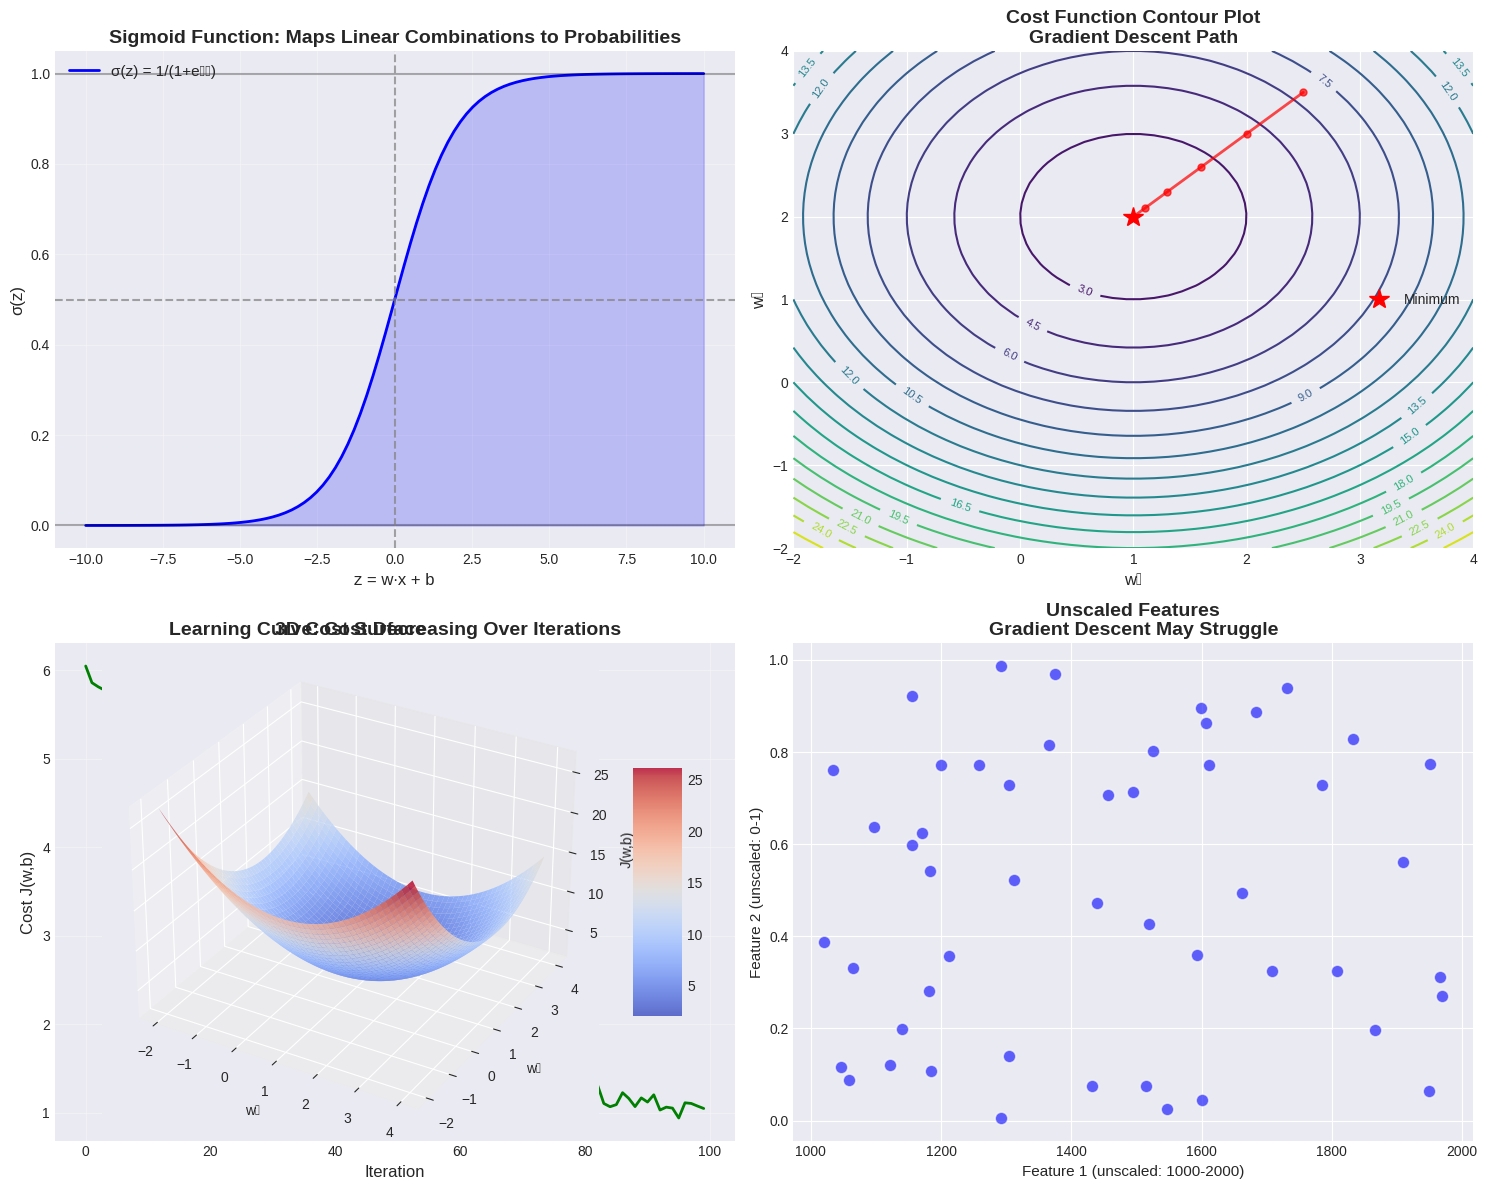

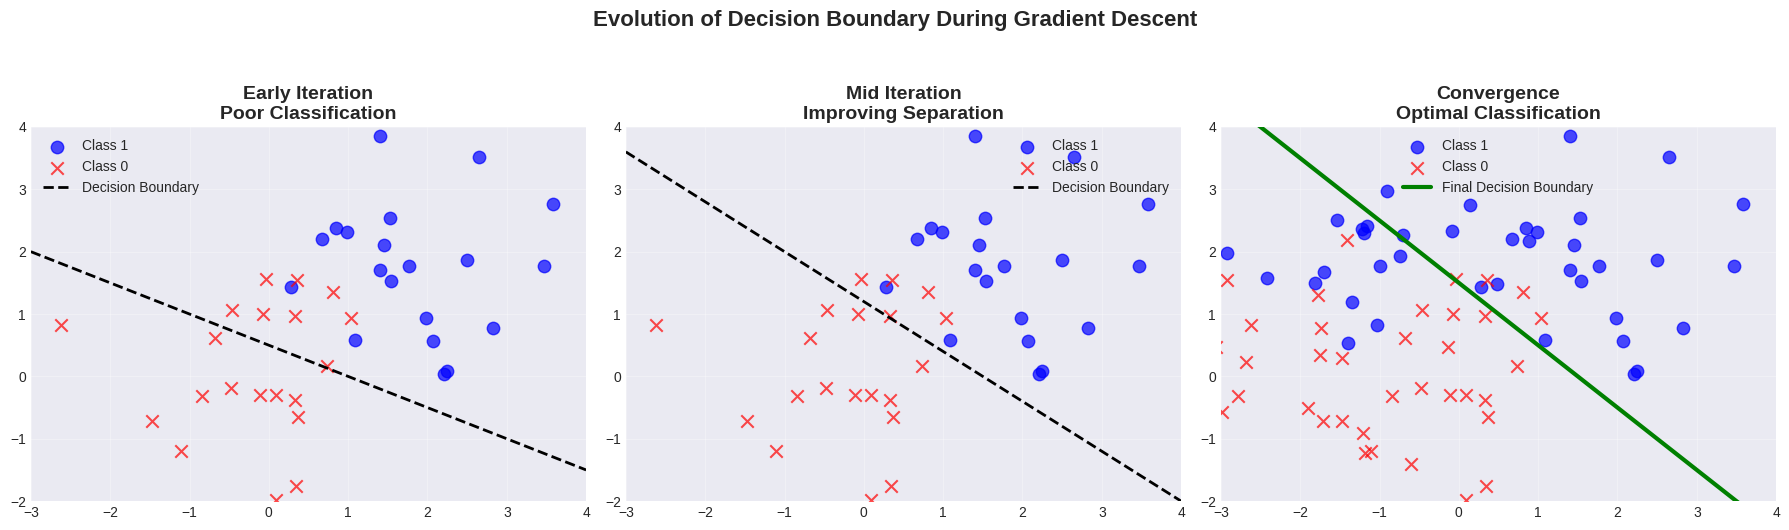

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')

# Figure 1: Sigmoid Function
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Sigmoid function plot
z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))

axes[0, 0].plot(z, sigmoid, 'b-', linewidth=2, label='σ(z) = 1/(1+e⁻ᶻ)')
axes[0, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
axes[0, 0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[0, 0].axhline(y=1, color='black', linestyle='-', alpha=0.3)
axes[0, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.7)
axes[0, 0].fill_between(z, 0, sigmoid, alpha=0.2, color='blue')
axes[0, 0].set_xlabel('z = w·x + b', fontsize=12)
axes[0, 0].set_ylabel('σ(z)', fontsize=12)
axes[0, 0].set_title('Sigmoid Function: Maps Linear Combinations to Probabilities', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# 2. Cost Surface Contour
# Generate synthetic data for visualization
np.random.seed(42)
w1 = np.linspace(-2, 4, 50)
w2 = np.linspace(-2, 4, 50)
W1, W2 = np.meshgrid(w1, w2)

# Create a simple cost function for visualization
Z = (W1 - 1)**2 + (W2 - 2)**2 + 2

contour = axes[0, 1].contour(W1, W2, Z, levels=20, cmap='viridis')
axes[0, 1].clabel(contour, inline=True, fontsize=8)
axes[0, 1].plot(1, 2, 'r*', markersize=15, label='Minimum')
axes[0, 1].set_xlabel('w₁', fontsize=12)
axes[0, 1].set_ylabel('w₂', fontsize=12)
axes[0, 1].set_title('Cost Function Contour Plot\nGradient Descent Path', fontsize=14, fontweight='bold')
axes[0, 1].legend()

# 3. Gradient Descent Steps on Contour
theta_path = np.array([[2.5, 3.5], [2.0, 3.0], [1.6, 2.6], [1.3, 2.3], [1.1, 2.1], [1.0, 2.0]])
axes[0, 1].plot(theta_path[:, 0], theta_path[:, 1], 'ro-', markersize=5, linewidth=2, alpha=0.7)

# 4. 3D Cost Surface
ax3d = fig.add_subplot(2, 2, 3, projection='3d')
surf = ax3d.plot_surface(W1, W2, Z, cmap=cm.coolwarm, alpha=0.8, linewidth=0)
ax3d.set_xlabel('w₁', fontsize=10)
ax3d.set_ylabel('w₂', fontsize=10)
ax3d.set_zlabel('J(w,b)', fontsize=10)
ax3d.set_title('3D Cost Surface', fontsize=14, fontweight='bold')
fig.colorbar(surf, ax=ax3d, shrink=0.5, aspect=5)

# 5. Learning Curve (Cost vs. Iterations)
iterations = np.arange(0, 100)
cost = 10 / (1 + np.exp(iterations/20)) + 1 + np.random.normal(0, 0.1, 100)

axes[1, 0].plot(iterations, cost, 'g-', linewidth=2)
axes[1, 0].set_xlabel('Iteration', fontsize=12)
axes[1, 0].set_ylabel('Cost J(w,b)', fontsize=12)
axes[1, 0].set_title('Learning Curve: Cost Decreasing Over Iterations', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 6. Feature Scaling Comparison
np.random.seed(42)
x1 = np.random.uniform(1000, 2000, 50)  # Large scale feature
x2 = np.random.uniform(0, 1, 50)         # Small scale feature

axes[1, 1].scatter(x1, x2, alpha=0.6, c='blue', edgecolors='w', s=80)
axes[1, 1].set_xlabel('Feature 1 (unscaled: 1000-2000)', fontsize=11)
axes[1, 1].set_ylabel('Feature 2 (unscaled: 0-1)', fontsize=11)
axes[1, 1].set_title('Unscaled Features\nGradient Descent May Struggle', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Figure 2: Decision Boundary Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Generate synthetic classification data
np.random.seed(42)
X1_pos = np.random.randn(20, 2) + np.array([2, 2])
X1_neg = np.random.randn(20, 2) + np.array([0, 0])
X2_pos = np.random.randn(20, 2) + np.array([-1, 2])
X2_neg = np.random.randn(20, 2) + np.array([-2, 0])

# Plot decision boundary evolution
# Early iteration
axes[0].scatter(X1_pos[:, 0], X1_pos[:, 1], c='blue', marker='o', s=80, alpha=0.7, label='Class 1')
axes[0].scatter(X1_neg[:, 0], X1_neg[:, 1], c='red', marker='x', s=80, alpha=0.7, label='Class 0')
x_line = np.linspace(-3, 4, 100)
y_line = -0.5 * x_line + 0.5  # Poor decision boundary
axes[0].plot(x_line, y_line, 'k--', linewidth=2, label='Decision Boundary')
axes[0].set_xlim(-3, 4)
axes[0].set_ylim(-2, 4)
axes[0].set_title('Early Iteration\nPoor Classification', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Mid iteration
axes[1].scatter(X1_pos[:, 0], X1_pos[:, 1], c='blue', marker='o', s=80, alpha=0.7, label='Class 1')
axes[1].scatter(X1_neg[:, 0], X1_neg[:, 1], c='red', marker='x', s=80, alpha=0.7, label='Class 0')
y_line = -0.8 * x_line + 1.2  # Improving boundary
axes[1].plot(x_line, y_line, 'k--', linewidth=2, label='Decision Boundary')
axes[1].set_xlim(-3, 4)
axes[1].set_ylim(-2, 4)
axes[1].set_title('Mid Iteration\nImproving Separation', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Convergence
axes[2].scatter(np.vstack([X1_pos, X2_pos])[:, 0], np.vstack([X1_pos, X2_pos])[:, 1],
                c='blue', marker='o', s=80, alpha=0.7, label='Class 1')
axes[2].scatter(np.vstack([X1_neg, X2_neg])[:, 0], np.vstack([X1_neg, X2_neg])[:, 1],
                c='red', marker='x', s=80, alpha=0.7, label='Class 0')
y_line = -x_line + 1.5  # Optimal boundary
axes[2].plot(x_line, y_line, 'g-', linewidth=3, label='Final Decision Boundary')
axes[2].set_xlim(-3, 4)
axes[2].set_ylim(-2, 4)
axes[2].set_title('Convergence\nOptimal Classification', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Evolution of Decision Boundary During Gradient Descent', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 6. Code Examples

Training Logistic Regression with Gradient Descent...
Iteration 0: Cost = 0.6931
Iteration 100: Cost = 0.0940
Iteration 200: Cost = 0.0544
Iteration 300: Cost = 0.0395
Iteration 400: Cost = 0.0315
Iteration 500: Cost = 0.0264
Iteration 600: Cost = 0.0229
Iteration 700: Cost = 0.0203
Iteration 800: Cost = 0.0183
Iteration 900: Cost = 0.0167

Accuracy: 0.9750

Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      0.95      0.97        19
     Class 1       0.95      1.00      0.98        21

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



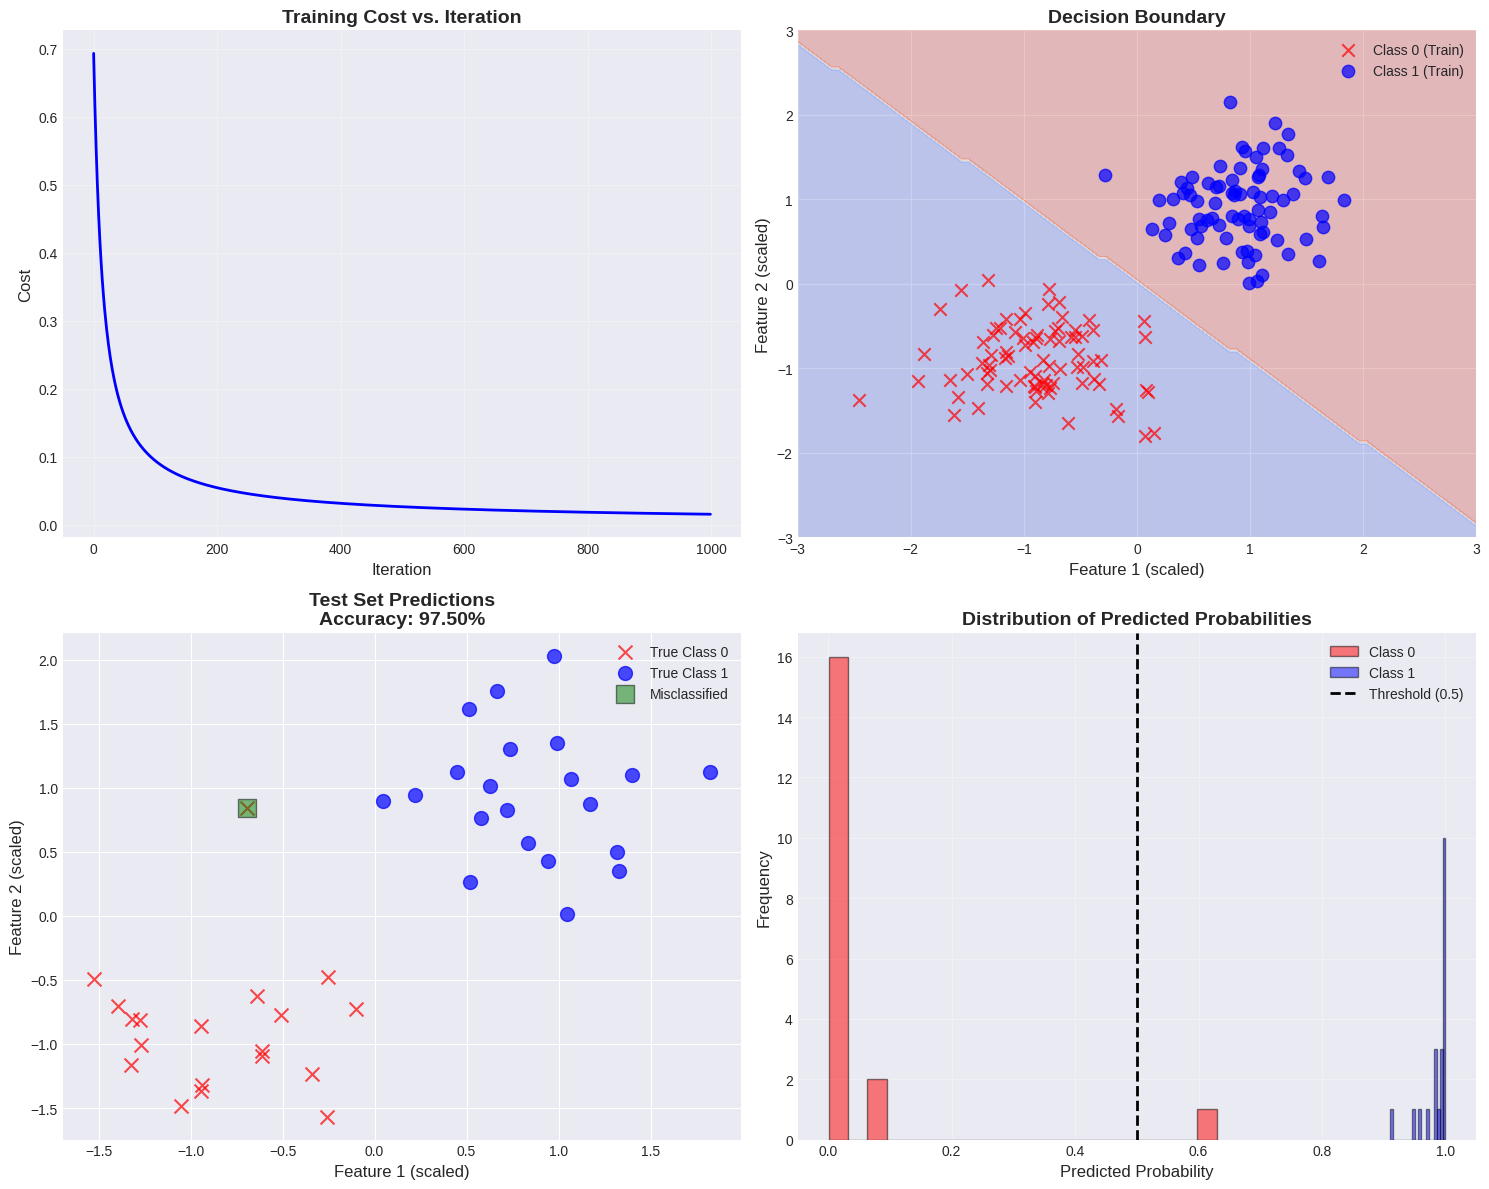


Scikit-learn Implementation (as mentioned in lecture)
Scikit-learn Accuracy: 0.9750

Our model weights: [2.97120362 3.13309025]
Scikit-learn weights: [2.39985477 2.5533852 ]
Our model bias: -0.0523
Scikit-learn bias: -0.0475


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

class LogisticRegressionGD:
    """
    Logistic Regression using Gradient Descent
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def sigmoid(self, z):
        """Sigmoid activation function"""
        # Clip to avoid overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        """Train the model using gradient descent"""
        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient descent
        for i in range(self.n_iterations):
            # Forward pass: compute predictions
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)

            # Compute gradients
            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1/n_samples) * np.sum(y_predicted - y)

            # Update parameters (simultaneous updates)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Compute and store cost (binary cross-entropy)
            cost = -(1/n_samples) * np.sum(y * np.log(y_predicted + 1e-15) +
                                           (1-y) * np.log(1 - y_predicted + 1e-15))
            self.cost_history.append(cost)

            # Print progress every 100 iterations
            if i % 100 == 0:
                print(f"Iteration {i}: Cost = {cost:.4f}")

    def predict_proba(self, X):
        """Predict probability of class 1"""
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        """Predict class labels (0 or 1)"""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

# Generate synthetic dataset for demonstration
np.random.seed(42)
n_samples = 200

# Create two clusters of data
X1 = np.random.randn(n_samples//2, 2) + np.array([2, 2])
X2 = np.random.randn(n_samples//2, 2) + np.array([-2, -2])
X = np.vstack([X1, X2])
y = np.hstack([np.ones(n_samples//2), np.zeros(n_samples//2)])

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (crucial for gradient descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
print("Training Logistic Regression with Gradient Descent...")
model = LogisticRegressionGD(learning_rate=0.1, n_iterations=1000)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Cost history
axes[0, 0].plot(model.cost_history, 'b-', linewidth=2)
axes[0, 0].set_xlabel('Iteration', fontsize=12)
axes[0, 0].set_ylabel('Cost', fontsize=12)
axes[0, 0].set_title('Training Cost vs. Iteration', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Decision boundary
xx, yy = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

axes[0, 1].contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
axes[0, 1].scatter(X_train_scaled[y_train==0, 0], X_train_scaled[y_train==0, 1],
                   c='red', marker='x', s=80, alpha=0.7, label='Class 0 (Train)')
axes[0, 1].scatter(X_train_scaled[y_train==1, 0], X_train_scaled[y_train==1, 1],
                   c='blue', marker='o', s=80, alpha=0.7, label='Class 1 (Train)')
axes[0, 1].set_xlabel('Feature 1 (scaled)', fontsize=12)
axes[0, 1].set_ylabel('Feature 2 (scaled)', fontsize=12)
axes[0, 1].set_title('Decision Boundary', fontsize=14, fontweight='bold')
axes[0, 1].legend()

# 3. Test set predictions
axes[1, 0].scatter(X_test_scaled[y_test==0, 0], X_test_scaled[y_test==0, 1],
                   c='red', marker='x', s=100, alpha=0.7, label='True Class 0')
axes[1, 0].scatter(X_test_scaled[y_test==1, 0], X_test_scaled[y_test==1, 1],
                   c='blue', marker='o', s=100, alpha=0.7, label='True Class 1')
# Mark misclassifications
misclassified = y_pred != y_test
axes[1, 0].scatter(X_test_scaled[misclassified, 0], X_test_scaled[misclassified, 1],
                   c='green', marker='s', s=150, alpha=0.5, label='Misclassified', edgecolors='black')
axes[1, 0].set_xlabel('Feature 1 (scaled)', fontsize=12)
axes[1, 0].set_ylabel('Feature 2 (scaled)', fontsize=12)
axes[1, 0].set_title(f'Test Set Predictions\nAccuracy: {accuracy:.2%}', fontsize=14, fontweight='bold')
axes[1, 0].legend()

# 4. Probability distribution
axes[1, 1].hist(y_pred_proba[y_test==0], bins=20, alpha=0.5, color='red', label='Class 0', edgecolor='black')
axes[1, 1].hist(y_pred_proba[y_test==1], bins=20, alpha=0.5, color='blue', label='Class 1', edgecolor='black')
axes[1, 1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[1, 1].set_xlabel('Predicted Probability', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Scikit-learn comparison (as mentioned in the lecture)
from sklearn.linear_model import LogisticRegression

print("\n" + "="*50)
print("Scikit-learn Implementation (as mentioned in lecture)")
print("="*50)

sk_model = LogisticRegression()
sk_model.fit(X_train_scaled, y_train)
sk_pred = sk_model.predict(X_test_scaled)
sk_accuracy = accuracy_score(y_test, sk_pred)
print(f"Scikit-learn Accuracy: {sk_accuracy:.4f}")

# Compare coefficients
print(f"\nOur model weights: {model.weights}")
print(f"Scikit-learn weights: {sk_model.coef_[0]}")
print(f"Our model bias: {model.bias:.4f}")
print(f"Scikit-learn bias: {sk_model.intercept_[0]:.4f}")

## 7. Key Takeaways

1. **Same Update, Different Function**: Gradient descent for logistic regression uses the same mathematical update equations as linear regression, but the prediction function f(x) is fundamentally different (sigmoid vs. linear).

2. **Probabilistic Output**: Logistic regression outputs probabilities between 0 and 1, making it suitable for classification tasks where uncertainty quantification is valuable.

3. **Simultaneous Updates Critical**: Always compute all gradients using current parameter values before applying any updates to ensure mathematically correct gradient descent.

4. **Feature Scaling is Essential**: Logistic regression gradient descent benefits significantly from feature scaling, just like linear regression, due to the gradient calculation's dependence on feature magnitudes.

5. **Convergence Monitoring**: The learning curve (cost vs. iterations) remains a reliable tool for diagnosing convergence issues in logistic regression.

6. **Vectorization Benefits**: Implementing logistic regression with vectorized operations (using NumPy) dramatically improves computational efficiency, especially with large datasets.

7. **Threshold Selection**: The default classification threshold is 0.5, but this can be adjusted based on the specific costs of false positives and false negatives in your application.

## 8. Quick Revision

### Key Formulas

**Logistic Regression Prediction:**
$$f_{\vec{w},b}(\vec{x}) = \frac{1}{1+e^{-(\vec{w} \cdot \vec{x} + b)}}$$

Where:
- $\vec{w}$ = weight vector
- $b$ = bias term
- $\vec{x}$ = input features
- $f_{\vec{w},b}(\vec{x})$ = probability that y = 1

**Gradient Descent Updates:**
$$w_j = w_j - \alpha \left[\frac{1}{m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})x_j^{(i)}\right]$$
$$b = b - \alpha \left[\frac{1}{m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})\right]$$

Where:
- $\alpha$ = learning rate
- $m$ = number of training examples
- $f_{\vec{w},b}(\vec{x}^{(i)})$ = prediction for example i
- $y^{(i)}$ = actual label for example i
- $x_j^{(i)}$ = j-th feature of example i

### Critical Concepts

| Concept | Description | Key Point |
|--------|-------------|-----------|
| **Sigmoid Function** | Maps linear combination to [0,1] | Enables probability interpretation |
| **Gradient Descent** | Iterative optimization | Updates parameters to minimize cost |
| **Simultaneous Updates** | Update all params at once | Maintains mathematical consistency |
| **Feature Scaling** | Normalize input ranges | Accelerates convergence |
| **Binary Cross-Entropy** | Cost function for logistic regression | Measures prediction error |

### Common Pitfalls to Avoid

1. **Sequential Updates**: Always compute all gradients before updating any parameters
2. **Unscaled Features**: Always scale features for faster, more reliable convergence
3. **Wrong Threshold**: 0.5 is default but not always optimal for your specific problem
4. **Ignoring Convergence**: Monitor learning curve to ensure proper training